# Part 1.3 (b): Predicting Food Delivery Time

**Dataset:** Food Delivery Dataset (gauravmalik26),
<https://www.kaggle.com/datasets/gauravmalik26/food-delivery-dataset>

**Question:** given the courier, the conditions and the trip, how many minutes will this delivery
take?

Notebook 01 looked at the marketplace and merchant end of delivery. This one looks at the
**courier end** of the same pipeline, at a completely different time scale. The Olist data has no
courier attributes at all, and this data has no merchant information, so together they cover
opposite halves of one problem. They share no key, geography or period, so they are never merged.

The same two algorithms are used in regression form: `XGBRegressor` and `SVR`.

**Run notebook 01 first.** The final step reads its importance table to build the single figure
used in the report.

## Step 1: Imports

In [1]:
import time
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
print("libraries imported")

libraries imported


## Step 2: Paths and configuration

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd().parent
FOOD_DIR = ROOT / "food_delivery"
OUTPUT_DIR = ROOT / "analysis" / "outputs"
IMG_DIR = ROOT / "analysis" / "img"          # the report figure is written here
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)

SVM_TRAIN_CAP = 15_000    # same reason as notebook 01: RBF fitting is roughly O(n^2)

print(f"reading from {FOOD_DIR}\nfigure written to {IMG_DIR}")

reading from /Users/ashish/Desktop/RMIT/Case studies/food_delivery
figure written to /Users/ashish/Desktop/RMIT/Case studies/analysis/img


## Step 3: Load and inspect the damage

This is a community upload rather than an official release, and it shows. Almost every column
arrives as text because missing values were written into the file as the literal string `NaN`.

In [3]:
food = pd.read_csv(FOOD_DIR / "train.csv")
print(f"{food.shape[0]:,} rows x {food.shape[1]} columns\n")
print("columns arriving as text that should be numeric:")
print("  Delivery_person_Age, Delivery_person_Ratings, multiple_deliveries, Time_taken(min)\n")
print(food[["Weatherconditions", "Road_traffic_density", "Time_taken(min)"]].head(3).to_string(index=False))

45,593 rows x 20 columns

columns arriving as text that should be numeric:
  Delivery_person_Age, Delivery_person_Ratings, multiple_deliveries, Time_taken(min)

    Weatherconditions Road_traffic_density Time_taken(min)
     conditions Sunny                High         (min) 24
    conditions Stormy                 Jam         (min) 33
conditions Sandstorms                 Low         (min) 26


## Step 4: Strip whitespace and convert the fake nulls

In [4]:
food_clean = food.copy()
for col in food_clean.select_dtypes(include="object").columns:
    food_clean[col] = food_clean[col].str.strip()
# The literal string "NaN" blocks numeric conversion until it becomes a real null.
food_clean = food_clean.replace("NaN", np.nan)

missing = food_clean.isna().sum()
print(missing[missing > 0].to_string())

Delivery_person_Age        1854
Delivery_person_Ratings    1908
Time_Orderd                1731
Road_traffic_density        601
multiple_deliveries         993
Festival                    228
City                       1200


## Step 5: Strip the text prefixes, and a trap worth naming

`Weatherconditions` arrives as `"conditions Sunny"` and the target as `"(min) 24"`, so both need
their prefix removed.

The trap: missing weather was written as `"conditions NaN"`, which does **not** match the plain
`"NaN"` cleaned up in Step 4, so it survives and would be encoded as a real weather category called
"NaN". This was only caught when a spurious `Weatherconditions_NaN` column appeared in the model
input on the first run. It has to be converted a second time, after the prefix is gone.

In [5]:
food_clean["Weatherconditions"] = food_clean["Weatherconditions"].str.replace(
    "conditions ", "", regex=False)
hidden = (food_clean["Weatherconditions"] == "NaN").sum()
food_clean["Weatherconditions"] = food_clean["Weatherconditions"].replace("NaN", np.nan)
print(f"hidden missing weather values recovered: {hidden:,}")

# "(min) 24" -> 24. This is the target.
food_clean["time_taken_min"] = food_clean["Time_taken(min)"].str.extract(r"(\d+)").astype(float)
print(f"target: mean {food_clean['time_taken_min'].mean():.1f} min, "
      f"range {food_clean['time_taken_min'].min():.0f} to {food_clean['time_taken_min'].max():.0f}")

hidden missing weather values recovered: 616
target: mean 26.3 min, range 10 to 54


## Step 6: Convert the numeric columns

In [6]:
for col in ["Delivery_person_Age", "Delivery_person_Ratings", "multiple_deliveries"]:
    food_clean[col] = pd.to_numeric(food_clean[col], errors="coerce")  # coerce, do not raise
print(food_clean[["Delivery_person_Age", "Delivery_person_Ratings",
                  "multiple_deliveries"]].describe().round(2).T[["mean", "min", "max"]].to_string())

                          mean   min   max
Delivery_person_Age      29.57  15.0  50.0
Delivery_person_Ratings   4.63   1.0   6.0
multiple_deliveries       0.74   0.0   3.0


## Step 7: Fix the coordinates

Some coordinates are negative even though India sits entirely north of the equator and east of
Greenwich, so the sign is a data entry artefact. Others sit at almost exactly zero, which is a
placeholder for an unknown location rather than a real point in the Atlantic, and those rows are
dropped because distance cannot be recovered for them.

In [7]:
coord_cols = ["Restaurant_latitude", "Restaurant_longitude",
              "Delivery_location_latitude", "Delivery_location_longitude"]
for col in coord_cols:
    food_clean[col] = food_clean[col].abs()

placeholder = (food_clean[coord_cols] < 1).any(axis=1)
print(f"placeholder coordinates: {placeholder.sum():,} ({placeholder.mean():.2%})")
food_clean = food_clean[~placeholder].copy()
print(f"rows remaining         : {len(food_clean):,}")

placeholder coordinates: 3,640 (7.98%)
rows remaining         : 41,953


## Step 8: Trip distance and time features

In [8]:
def haversine_km(lat1, lon1, lat2, lon2):
    radius = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = (np.sin((lat2 - lat1) / 2) ** 2
         + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2)
    return 2 * radius * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

food_clean["distance_km"] = haversine_km(
    food_clean["Restaurant_latitude"], food_clean["Restaurant_longitude"],
    food_clean["Delivery_location_latitude"], food_clean["Delivery_location_longitude"])

food_clean["order_date"] = pd.to_datetime(food_clean["Order_Date"], format="%d-%m-%Y", errors="coerce")
food_clean["order_weekday"] = food_clean["order_date"].dt.dayofweek
food_clean["is_weekend"] = (food_clean["order_weekday"] >= 5).astype(int)

ordered = pd.to_timedelta(food_clean["Time_Orderd"], errors="coerce")
picked = pd.to_timedelta(food_clean["Time_Order_picked"], errors="coerce")
prep = (picked - ordered).dt.total_seconds() / 60.0
food_clean["prep_minutes"] = prep.where(prep >= 0, prep + 24 * 60)   # pickup can cross midnight
food_clean["order_hour"] = ordered.dt.total_seconds() // 3600

print(f"median trip {food_clean['distance_km'].median():.1f} km "
      f"(Olist parcels averaged hundreds of km, so the two operate at different scales)")

median trip 9.2 km (Olist parcels averaged hundreds of km, so the two operate at different scales)


## Step 9: Drop rows with no target, and check the festival effect

A regression cannot learn from a row whose target is unknown, but missing values in the *features*
are kept and handled by the models. The festival comparison is quoted in the report.

In [9]:
food_clean = food_clean.dropna(subset=["time_taken_min"]).copy()
print(f"rows for modelling: {len(food_clean):,}\n")
print("mean delivery time in minutes:")
print(food_clean.groupby("Festival")["time_taken_min"].mean().round(1).to_string())
print(f"overall mean: {food_clean['time_taken_min'].mean():.1f}")

rows for modelling: 41,953

mean delivery time in minutes:
Festival
No     26.0
Yes    45.5
overall mean: 26.3


## Step 10: Feature matrix and split

In [10]:
NUMERIC_FEATURES = ["distance_km", "prep_minutes", "Delivery_person_Age",
                    "Delivery_person_Ratings", "Vehicle_condition", "multiple_deliveries",
                    "order_weekday", "is_weekend", "order_hour"]
CATEGORICAL_FEATURES = ["Road_traffic_density", "Weatherconditions", "Type_of_order",
                        "Type_of_vehicle", "Festival", "City"]
# Excluded: ID and Delivery_person_ID (identifiers), raw coordinates (now distance_km).

X = pd.get_dummies(food_clean[NUMERIC_FEATURES + CATEGORICAL_FEATURES],
                   columns=CATEGORICAL_FEATURES)
y = food_clean["time_taken_min"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
# No stratification: the target is continuous, so a random split is already representative.
print(f"features {X.shape[1]} | train {len(X_train):,} | test {len(X_test):,}")

features 32 | train 33,562 | test 8,391


## Step 11: Train both models, against a baseline

The baseline predicts the mean delivery time for every order. Including it is what makes the
improvement visible rather than assumed: any model has to beat it to have earned its place.

In [11]:
baseline_pred = np.full(len(y_test), y_train.mean())

xgb = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.08,
                   subsample=0.9, colsample_bytree=0.9,
                   random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)

X_svm, _, y_svm, _ = train_test_split(X_train, y_train, train_size=SVM_TRAIN_CAP,
                                      random_state=RANDOM_STATE)
start = time.time()
svm = Pipeline([("impute", SimpleImputer(strategy="median")),
                ("scale", StandardScaler()),
                ("reg", SVR(kernel="rbf", C=10.0, gamma="scale", cache_size=1000))]).fit(X_svm, y_svm)
print(f"SVR fitted on {len(X_svm):,} of {len(X_train):,} training rows in {time.time()-start:.1f}s")

SVR fitted on 15,000 of 33,562 training rows in 4.1s


## Step 12: Evaluate

Mean absolute error is the headline metric because it reads directly as how wrong a customer-facing
estimate is likely to be. Root mean squared error sits beside it because it penalises the large
misses that do most damage to trust, and a gap between the two signals occasional bad predictions.

In [12]:
def evaluate(name, pred):
    return {"model": name,
            "mae_minutes": mean_absolute_error(y_test, pred),
            "rmse_minutes": np.sqrt(mean_squared_error(y_test, pred)),
            "r2": r2_score(y_test, pred),
            # Safe here because no delivery takes anywhere near zero minutes.
            "mape_pct": np.mean(np.abs((y_test - pred) / y_test)) * 100}

metrics = pd.DataFrame([
    evaluate("Food delivery - Baseline (mean)", baseline_pred),
    evaluate("Food delivery - XGBoost", xgb.predict(X_test)),
    evaluate("Food delivery - SVM", svm.predict(X_test)),
])
metrics.to_csv(OUTPUT_DIR / "metrics_food.csv", index=False)
print(metrics.round(3).to_string(index=False))

cut = 1 - metrics.loc[1, "mae_minutes"] / metrics.loc[0, "mae_minutes"]
print(f"\nXGBoost cuts the average ETA error by {cut:.0%} against the baseline")

                          model  mae_minutes  rmse_minutes     r2  mape_pct
Food delivery - Baseline (mean)        7.508         9.282 -0.000    34.149
        Food delivery - XGBoost        3.112         3.921  0.822    13.401
            Food delivery - SVM        3.840         4.910  0.720    16.569

XGBoost cuts the average ETA error by 59% against the baseline


## Step 13: What drives delivery time

In [13]:
PERM_SAMPLE = 5000
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), PERM_SAMPLE, replace=False)
result = permutation_importance(
    xgb, X_test.iloc[idx], y_test.iloc[idx],
    scoring="neg_mean_absolute_error",     # keeps the units in minutes
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
imp_food = (pd.DataFrame({"feature": X_test.columns, "importance": result.importances_mean})
            .sort_values("importance", ascending=False).reset_index(drop=True))
imp_food.to_csv(OUTPUT_DIR / "food_importance_xgb.csv", index=False)
print(imp_food.head(8).round(3).to_string(index=False))

                 feature  importance
             distance_km       1.648
     Delivery_person_Age       1.343
Road_traffic_density_Low       1.205
       Vehicle_condition       1.037
 Delivery_person_Ratings       1.000
 Weatherconditions_Sunny       0.684
Weatherconditions_Cloudy       0.663
   Weatherconditions_Fog       0.644


## Step 14: The report figure

The one figure used in the report. Plotting both data sets side by side is what makes the central
argument visible: they identify different drivers because they cover opposite ends of the same
delivery pipeline, which is why the two sources are complementary rather than contradicting.

Reads notebook 01's importance table, so run that first. Saved as vector PDF for LaTeX.

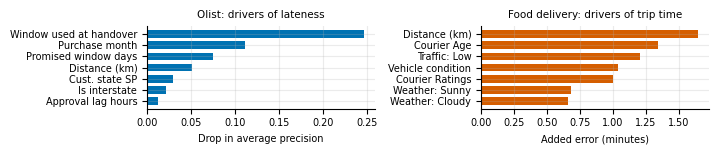

saved /Users/ashish/Desktop/RMIT/Case studies/analysis/img/importance_combined.pdf


In [14]:
imp_olist = pd.read_csv(OUTPUT_DIR / "olist_importance_xgb.csv")

mpl.rcParams.update({"savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 7,
                     "axes.titlesize": 7.5, "axes.labelsize": 7,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

def pretty(s):
    s = (s.replace("_", " ").replace("Road traffic density ", "traffic: ")
          .replace("Weatherconditions ", "weather: ").replace("customer state ", "cust. state ")
          .replace("Delivery person ", "courier ").replace("km", "(km)"))
    return s[0].upper() + s[1:]

fig, axes = plt.subplots(1, 2, figsize=(7.2, 1.55))
for ax, d, title, colour, xlabel in [
    (axes[0], imp_olist, "Olist: drivers of lateness", "#0072B2", "Drop in average precision"),
    (axes[1], imp_food, "Food delivery: drivers of trip time", "#D55E00", "Added error (minutes)"),
]:
    top = d.head(7).iloc[::-1]          # top 7, matching the figure in the submitted report
    ax.barh([pretty(f) for f in top["feature"]], top["importance"], color=colour, height=0.68)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
fig.tight_layout(w_pad=1.2)
fig.savefig(IMG_DIR / "importance_combined.pdf")     # vector, stays sharp in the report
plt.show()
print(f"saved {IMG_DIR / 'importance_combined.pdf'}")

## Findings

1. **Conditions in transit dominate**: distance, traffic and courier attributes drive trip time,
   and festival periods add roughly 20 minutes.
2. **The Olist data contains none of these attributes**, which is why the two sources are
   complementary rather than contradicting.
3. Distance ranks first here but only fourth on Olist. That is a difference of scale, not a
   contradiction: these are sub-hour intra-city trips against multi-day interstate parcels whose
   promised window already absorbs distance.
4. Gradient boosting beats the support vector machine on both data sets, as expected for
   heterogeneous tabular data.